# K-means clustering - Classificador Binário

### 1. Setup inicial

In [1]:
import os, random, warnings, copy, math, time
from pathlib import Path
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from PIL import Image

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import (classification_report, confusion_matrix, f1_score, accuracy_score,
                             roc_auc_score, roc_curve, precision_recall_curve)
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

try:
    import cv2
    CV2_AVAILABLE = True
except Exception:
    CV2_AVAILABLE = False

SEED = 42
def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", device)
seed_everything()

ENABLE_CIRCULAR_CROP = True
ENABLE_CLAHE = True
CLAHE_CLIP = 2.0
CLAHE_GRID = 8

SWEEP_LR = [1e-4, 3e-4]
SWEEP_WD = [1e-5, 1e-4]
SWEEP_DROPOUT = [0.2, 0.4]
SWEEP_EPOCHS = 6
FINAL_EPOCHS = 15
PRETRAIN_EPOCHS = 5
BATCH_SIZE = 32

Dispositivo: cpu


### 2. Carregamento do dataset

In [2]:
CSV_PATH = "/kaggle/input/idrid-dataset/idrid_labels.csv"
IMG_DIR  = "/kaggle/input/idrid-dataset/Imagenes/Imagenes"

try:
    df = pd.read_csv(CSV_PATH)
    df.columns = [c.strip() for c in df.columns]
except Exception:
    df = pd.read_csv(CSV_PATH, usecols=[0,1], header=0)
    df.columns = ["id_code", "diagnosis"]

cols = [c for c in df.columns if c.lower() in ("id_code", "diagnosis")]
df = df[cols].copy()
df.columns = ["id_code", "diagnosis"]
df["diagnosis"] = df["diagnosis"].astype(int)
df["label"] = (df["diagnosis"] > 0).astype(int)

def build_img_path(id_code):
    base = Path(IMG_DIR) / f"{id_code}"
    for ext in [".jpg", ".JPG", ".png", ".jpeg", ".JPEG"]:
        p = base.with_suffix(ext)
        if p.exists():
            return str(p)
    return str(base.with_suffix(".jpg"))

df["image_path"] = df["id_code"].apply(build_img_path)
print(df.head())
print("\nDistribuição de Classes:\n", df["label"].value_counts().sort_index())

     id_code  diagnosis  label  \
0  IDRiD_001          3      1   
1  IDRiD_002          3      1   
2  IDRiD_003          2      1   
3  IDRiD_004          3      1   
4  IDRiD_005          4      1   

                                          image_path  
0  /kaggle/input/idrid-dataset/Imagenes/Imagenes/...  
1  /kaggle/input/idrid-dataset/Imagenes/Imagenes/...  
2  /kaggle/input/idrid-dataset/Imagenes/Imagenes/...  
3  /kaggle/input/idrid-dataset/Imagenes/Imagenes/...  
4  /kaggle/input/idrid-dataset/Imagenes/Imagenes/...  

Distribuição de Classes:
 label
0    129
1    326
Name: count, dtype: int64


### 3. Particionamento do dataset

In [3]:
sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=SEED)
train_idx, temp_idx = next(sss1.split(df, df["label"]))
train_df = df.iloc[train_idx].reset_index(drop=True)
temp_df  = df.iloc[temp_idx].reset_index(drop=True)

sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=SEED)
val_idx, test_idx = next(sss2.split(temp_df, temp_df["label"]))
val_df  = temp_df.iloc[val_idx].reset_index(drop=True)
test_df = temp_df.iloc[test_idx].reset_index(drop=True)

for name, d in [("Treinamento (70%)", train_df), ("Validação (15%)", val_df), ("Teste (15%)", test_df)]:
    print(f"{name}: Total de {len(d)} imagens")
    print(d["label"].value_counts().sort_index(), "\n")

Treinamento (70%): Total de 318 imagens
label
0     90
1    228
Name: count, dtype: int64 

Validação (15%): Total de 68 imagens
label
0    19
1    49
Name: count, dtype: int64 

Teste (15%): Total de 69 imagens
label
0    20
1    49
Name: count, dtype: int64 



### 4. Pré-processamento das imagens

In [4]:
import numpy as np
from PIL import Image

def center_square_crop(np_img):
    h, w = np_img.shape[:2]
    s = min(h, w)
    y0 = (h - s) // 2
    x0 = (w - s) // 2
    return np_img[y0:y0+s, x0:x0+s]

def circular_crop(np_img, margin=0.02):
    sq = center_square_crop(np_img)
    h, w = sq.shape[:2]
    r = int(0.5 * min(h, w) * (1.0 - margin))
    cy, cx = h // 2, w // 2
    Y, X = np.ogrid[:h, :w]
    mask = (X - cx)**2 + (Y - cy)**2 <= r*r
    out = np.zeros_like(sq)
    out[mask] = sq[mask]
    return out

def apply_clahe_green(np_img, clip=2.0, grid=8):
    try:
        import cv2
        bgr = cv2.cvtColor(np_img, cv2.COLOR_RGB2BGR)
        g = bgr[:,:,1]
        clahe = cv2.createCLAHE(clipLimit=float(clip), tileGridSize=(int(grid), int(grid)))
        g_eq = clahe.apply(g)
        bgr[:,:,1] = g_eq
        rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
        return rgb
    except Exception:
        g = np_img[:,:,1].astype(np.float32)
        g = (g - g.min()) / max(1e-6, (g.max()-g.min()))
        g = (g * 255.0).astype(np.uint8)
        np_img2 = np_img.copy()
        np_img2[:,:,1] = g
        return np_img2

class Preprocessor:
    def __init__(self, circ=True, clahe=True, clip=2.0, grid=8):
        self.circ = circ
        self.clahe = clahe
        self.clip = clip
        self.grid = grid
    def __call__(self, pil_img):
        np_img = np.array(pil_img)
        if self.circ:
            np_img = circular_crop(np_img, margin=0.02)
        if self.clahe:
            np_img = apply_clahe_green(np_img, clip=self.clip, grid=self.grid)
        return Image.fromarray(np_img)

ENABLE_CIRCULAR_CROP = True
ENABLE_CLAHE = True
CLAHE_CLIP = 2.0
CLAHE_GRID = 8
preproc = Preprocessor(ENABLE_CIRCULAR_CROP, ENABLE_CLAHE, CLAHE_CLIP, CLAHE_GRID)

### 5. Dataset, Transforms & Loaders

In [5]:
from torchvision import transforms
from torch.utils.data import DataLoader, WeightedRandomSampler

train_tfms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.85, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

eval_tfms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

class IDRiDDataset(Dataset):
    def __init__(self, df, transform, preproc=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.preproc = preproc
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["image_path"]).convert("RGB")
        if self.preproc is not None:
            img = self.preproc(img)
        img = self.transform(img)
        label = int(row["label"])   # binary
        return img, label, row["id_code"]

train_ds = IDRiDDataset(train_df, train_tfms, preproc=preproc)
val_ds   = IDRiDDataset(val_df,   eval_tfms, preproc=preproc)
test_ds  = IDRiDDataset(test_df,  eval_tfms, preproc=preproc)

def make_loader(ds, shuffle, weighted=False):
    if not weighted:
        return DataLoader(ds, batch_size=32, shuffle=shuffle, num_workers=2, pin_memory=True)
    labels = [lab for _, lab, _ in ds]
    class_counts = np.bincount(labels, minlength=2)
    class_weights = 1.0 / (class_counts + 1e-6)
    sample_weights = [class_weights[lab] for lab in labels]
    sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)
    return DataLoader(ds, batch_size=32, sampler=sampler, num_workers=2, pin_memory=True)

train_loader = make_loader(train_ds, shuffle=True, weighted=True)
val_loader   = make_loader(val_ds,   shuffle=False)
test_loader  = make_loader(test_ds,  shuffle=False)

### 6. Extração de Embeddings com EfficientNet

In [6]:
try:
    from torchvision.models import EfficientNet_B0_Weights
    weights = EfficientNet_B0_Weights.IMAGENET1K_V1
    backbone = models.efficientnet_b0(weights=weights)
except Exception:
    backbone = models.efficientnet_b0(pretrained=True)

embed_net = copy.deepcopy(backbone)
embed_net.classifier = nn.Identity()
embed_net = embed_net.to(device)
embed_net.eval()

@torch.no_grad()
def extract_embeddings(dloader):
    feats, lbls, ids = [], [], []
    for x, y, idc in dloader:
        x = x.to(device)
        f = embed_net(x)
        feats.append(f.cpu().numpy())
        lbls.append(y.numpy())
        ids.extend(list(idc))
    return np.concatenate(feats), np.concatenate(lbls), ids

print("Extração de Embeddings (treino/validação/teste)...")
train_feats, train_lbls, train_ids = extract_embeddings(make_loader(train_ds, shuffle=False))
val_feats,   val_lbls,   val_ids   = extract_embeddings(val_loader)
test_feats,  test_lbls,  test_ids  = extract_embeddings(test_loader)
print("Formatos:", train_feats.shape, val_feats.shape, test_feats.shape)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:00<00:00, 103MB/s] 


Extração de Embeddings (treino/validação/teste)...
Formatos: (318, 1280) (68, 1280) (69, 1280)


### 7. K-Means (2 clusters) Pseudo-Labels + t-SNE

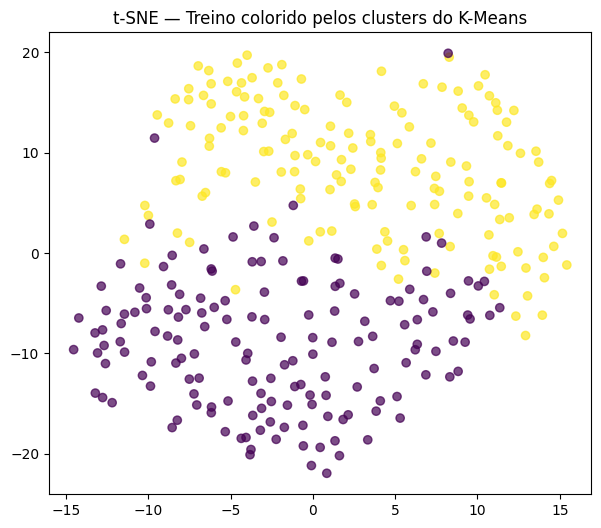

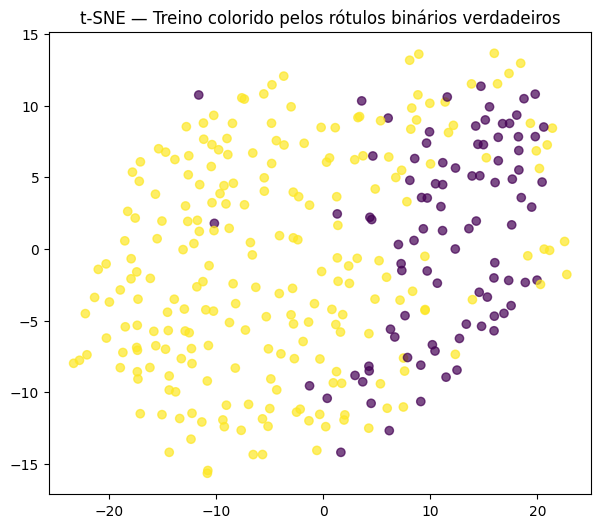

In [7]:
n_clusters = 2
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
train_clusters = kmeans.fit_predict(train_feats)
val_clusters   = kmeans.predict(val_feats)
test_clusters  = kmeans.predict(test_feats)

def tsne_plot(feats, labels, title):
    pca = PCA(n_components=min(50, feats.shape[1]))
    reduced = pca.fit_transform(feats)
    tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(reduced)-1))
    xy = tsne.fit_transform(reduced)
    plt.figure(figsize=(7,6))
    plt.scatter(xy[:,0], xy[:,1], c=labels, alpha=0.7)
    plt.title(title); plt.show()

tsne_plot(train_feats, train_clusters, "t-SNE — Treino colorido pelos clusters do K-Means")
tsne_plot(train_feats, train_lbls,     "t-SNE — Treino colorido pelos rótulos binários verdadeiros")

### 8. Pré-treinamento com Pseudo-Labels

[Pré-treinamento] Época: 01/5 | Loss/Treinamento=0.4761 Acurácia=0.7987 | Loss/Validação=0.2611 Acurácia=0.9559
[Pré-treinamento] Época: 02/5 | Loss/Treinamento=0.1850 Acurácia=0.9403 | Loss/Validação=0.1447 Acurácia=0.9412
[Pré-treinamento] Época: 03/5 | Loss/Treinamento=0.1327 Acurácia=0.9465 | Loss/Validação=0.0917 Acurácia=0.9706
[Pré-treinamento] Época: 04/5 | Loss/Treinamento=0.1248 Acurácia=0.9497 | Loss/Validação=0.1717 Acurácia=0.9559
[Pré-treinamento] Época: 05/5 | Loss/Treinamento=0.0639 Acurácia=0.9780 | Loss/Validação=0.1646 Acurácia=0.9559


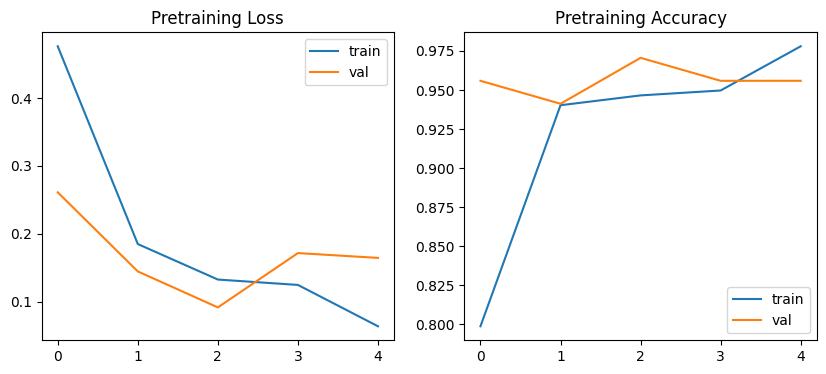

In [8]:
def make_model(num_out, dropout_p=0.2):
    model = copy.deepcopy(backbone)
    in_features = model.classifier[-1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=dropout_p, inplace=True),
        nn.Linear(in_features, num_out)
    )
    return model.to(device)

cluster_model = make_model(n_clusters, dropout_p=0.2)

class PseudoLabelDataset(Dataset):
    def __init__(self, base_ds, cluster_ids):
        self.base_ds = base_ds
        self.cluster_ids = cluster_ids
    def __len__(self):
        return len(self.base_ds)
    def __getitem__(self, idx):
        x, _, idc = self.base_ds[idx]
        return x, int(self.cluster_ids[idx]), idc

pseudo_train_ds = PseudoLabelDataset(train_ds, train_clusters)
pseudo_val_ds   = PseudoLabelDataset(val_ds,   val_clusters)

pseudo_train_loader = make_loader(pseudo_train_ds, shuffle=True, weighted=False)
pseudo_val_loader   = make_loader(pseudo_val_ds,   shuffle=False, weighted=False)

def train_one_epoch(model, loader, optim, criterion):
    model.train()
    total_loss, total_correct, total = 0.0, 0, 0
    for x, y, _ in loader:
        x, y = x.to(device), y.to(device)
        optim.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optim.step()
        total_loss += loss.item() * x.size(0)
        total_correct += (logits.argmax(1) == y).sum().item()
        total += x.size(0)
    return total_loss/total, total_correct/total

@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, total_correct, total = 0.0, 0, 0
    for x, y, _ in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)
        total_loss += loss.item() * x.size(0)
        total_correct += (logits.argmax(1) == y).sum().item()
        total += x.size(0)
    return total_loss/total, total_correct/total

optim_pre = torch.optim.AdamW(cluster_model.parameters(), lr=3e-4, weight_decay=1e-4)
criterion_pre = nn.CrossEntropyLoss()

hist_pre = {"train_loss":[], "train_acc":[], "val_loss":[], "val_acc":[]}
for epoch in range(1, PRETRAIN_EPOCHS+1):
    tr_loss, tr_acc = train_one_epoch(cluster_model, pseudo_train_loader, optim_pre, criterion_pre)
    va_loss, va_acc = eval_epoch(cluster_model, pseudo_val_loader, criterion_pre)
    hist_pre["train_loss"].append(tr_loss); hist_pre["train_acc"].append(tr_acc)
    hist_pre["val_loss"].append(va_loss);   hist_pre["val_acc"].append(va_acc)
    print(f"[Pré-treinamento] Época: {epoch:02d}/{PRETRAIN_EPOCHS} | Loss/Treinamento={tr_loss:.4f} Acurácia={tr_acc:.4f} | Loss/Validação={va_loss:.4f} Acurácia={va_acc:.4f}")

plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.plot(hist_pre["train_loss"], label="train"); plt.plot(hist_pre["val_loss"], label="val"); plt.title("Pretraining Loss"); plt.legend()
plt.subplot(1,2,2); plt.plot(hist_pre["train_acc"], label="train"); plt.plot(hist_pre["val_acc"], label="val"); plt.title("Pretraining Accuracy"); plt.legend()
plt.show()

### 9. Varredura de Hiperparâmetros para Fine-Tuning


=== Varredura: lr=0.0001, wd=1e-05, dropout=0.2 ===
Validação F1=0.8605 | Acurácia=0.8235

=== Varredura: lr=0.0001, wd=1e-05, dropout=0.4 ===
Validação F1=0.9111 | Acurácia=0.8824

=== Varredura: lr=0.0001, wd=0.0001, dropout=0.2 ===
Validação F1=0.9111 | Acurácia=0.8824

=== Varredura: lr=0.0001, wd=0.0001, dropout=0.4 ===
Validação F1=0.8989 | Acurácia=0.8676

=== Varredura: lr=0.0003, wd=1e-05, dropout=0.2 ===
Validação F1=0.9684 | Acurácia=0.9559

=== Varredura: lr=0.0003, wd=1e-05, dropout=0.4 ===
Validação F1=0.9583 | Acurácia=0.9412

=== Varredura: lr=0.0003, wd=0.0001, dropout=0.2 ===
Validação F1=0.9574 | Acurácia=0.9412

=== Varredura: lr=0.0003, wd=0.0001, dropout=0.4 ===
Validação F1=0.9247 | Acurácia=0.8971


,lr,wd,dropout,val_f1,val_acc
0,0.0003,0.00001,0.2,0.968421,0.955882
1,0.0003,0.00001,0.4,0.958333,0.941176
2,0.0003,0.00010,0.2,0.957447,0.941176
3,0.0003,0.00010,0.4,0.924731,0.897059
4,0.0001,0.00001,0.4,0.911111,0.882353
5,0.0001,0.00010,0.2,0.911111,0.882353
6,0.0001,0.00010,0.4,0.898876,0.867647
7,0.0001,0.00001,0.2,0.860465,0.823529


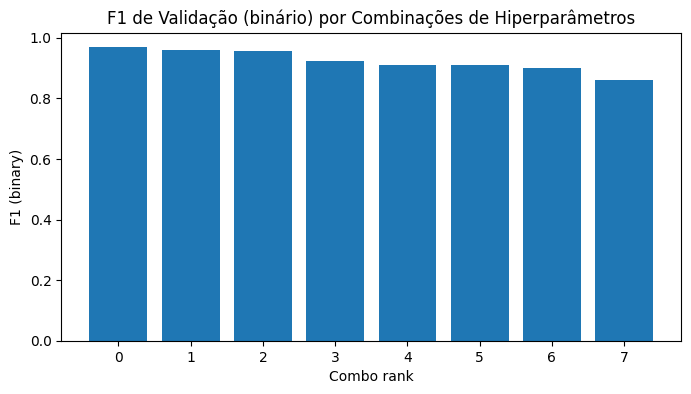

Melhores Hiperparâmetros: {'lr': 0.0003, 'wd': 1e-05, 'dropout': 0.2} Melhor F1: 0.968421052631579


In [9]:
from sklearn.metrics import accuracy_score, f1_score

NUM_CLASSES = 2

def make_finetune_model(from_model, num_out, dropout_p):
    m = copy.deepcopy(from_model)
    in_features = m.classifier[-1].in_features
    m.classifier = nn.Sequential(
        nn.Dropout(p=dropout_p, inplace=True),
        nn.Linear(in_features, num_out)
    )
    return m.to(device)

def evaluate_metrics(model, loader):
    model.eval()
    all_logits, all_y = [], []
    with torch.no_grad():
        for x, y, _ in loader:
            x = x.to(device)
            logits = model(x)
            all_logits.append(logits.cpu())
            all_y.append(y)
    all_logits = torch.cat(all_logits).numpy()
    all_y = torch.cat(all_y).numpy()
    preds = all_logits.argmax(1)
    acc = accuracy_score(all_y, preds)
    f1b = f1_score(all_y, preds, average="binary")
    return acc, f1b

class_counts = train_df["label"].value_counts().sort_index().values  # [count_0, count_1]
class_weights = torch.tensor(1.0/(class_counts + 1e-6), dtype=torch.float32).to(device)

results = []
best = {"f1": -1, "state": None, "hp": None}
for lr in SWEEP_LR:
    for wd in SWEEP_WD:
        for dp in SWEEP_DROPOUT:
            print(f"\n=== Varredura: lr={lr}, wd={wd}, dropout={dp} ===")
            model = make_finetune_model(cluster_model, NUM_CLASSES, dropout_p=dp)
            criterion = nn.CrossEntropyLoss(weight=class_weights)
            optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
            scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=SWEEP_EPOCHS)

            for ep in range(1, SWEEP_EPOCHS+1):
                model.train()
                for x, y, _ in train_loader:
                    x, y = x.to(device), y.to(device)
                    optimizer.zero_grad()
                    logits = model(x)
                    loss = criterion(logits, y)
                    loss.backward()
                    optimizer.step()
                scheduler.step()

            val_acc, val_f1 = evaluate_metrics(model, val_loader)
            results.append({"lr": lr, "wd": wd, "dropout": dp, "val_f1": val_f1, "val_acc": val_acc})
            print(f"Validação F1={val_f1:.4f} | Acurácia={val_acc:.4f}")
            if val_f1 > best["f1"]:
                best["f1"] = val_f1
                best["state"] = copy.deepcopy(model.state_dict())
                best["hp"] = {"lr": lr, "wd": wd, "dropout": dp}

res_df = pd.DataFrame(results).sort_values("val_f1", ascending=False).reset_index(drop=True)
display(res_df)

plt.figure(figsize=(8,4))
plt.bar(range(len(res_df)), res_df["val_f1"].values)
plt.title("F1 de Validação (binário) por Combinações de Hiperparâmetros")
plt.xlabel("Combo rank"); plt.ylabel("F1 (binary)")
plt.show()

print("Melhores Hiperparâmetros:", best["hp"], "Melhor F1:", best["f1"])

### 10. Fine-Tuning Final com os Melhores Hiperparâmetros e Testes

[Fine-Tuning Final] Época: 01/15 | Loss/Treinamento=0.3799 | Validação F1=0.8989 Acurácia=0.8676
[Fine-Tuning Final] Época: 02/15 | Loss/Treinamento=0.1472 | Validação F1=0.9231 Acurácia=0.8971
[Fine-Tuning Final] Época: 03/15 | Loss/Treinamento=0.1807 | Validação F1=0.9462 Acurácia=0.9265
[Fine-Tuning Final] Época: 04/15 | Loss/Treinamento=0.1046 | Validação F1=0.9462 Acurácia=0.9265
[Fine-Tuning Final] Época: 05/15 | Loss/Treinamento=0.1045 | Validação F1=0.9348 Acurácia=0.9118
[Fine-Tuning Final] Época: 06/15 | Loss/Treinamento=0.1208 | Validação F1=0.9348 Acurácia=0.9118
[Fine-Tuning Final] Época: 07/15 | Loss/Treinamento=0.0597 | Validação F1=0.9697 Acurácia=0.9559
[Fine-Tuning Final] Época: 08/15 | Loss/Treinamento=0.0506 | Validação F1=0.9462 Acurácia=0.9265
[Fine-Tuning Final] Época: 09/15 | Loss/Treinamento=0.0426 | Validação F1=0.9462 Acurácia=0.9265
[Fine-Tuning Final] Época: 10/15 | Loss/Treinamento=0.0453 | Validação F1=0.9462 Acurácia=0.9265
[Fine-Tuning Final] Época: 11/

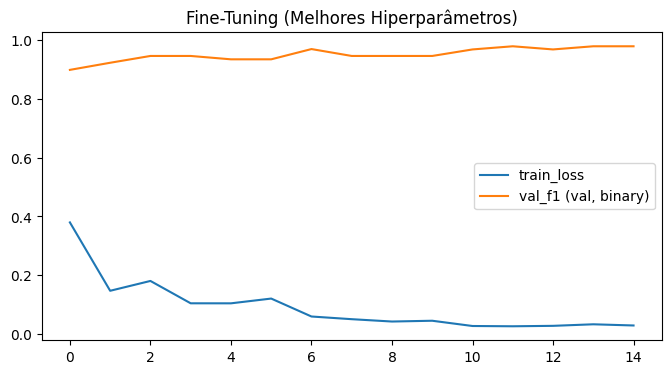

Test Accuracy: 0.9275 | Test F1 (binary): 0.9485

Relatório de Classificação (Teste):
              precision    recall  f1-score   support

   No DR (0)     0.8571    0.9000    0.8780        20
      DR (1)     0.9583    0.9388    0.9485        49

    accuracy                         0.9275        69
   macro avg     0.9077    0.9194    0.9133        69
weighted avg     0.9290    0.9275    0.9280        69



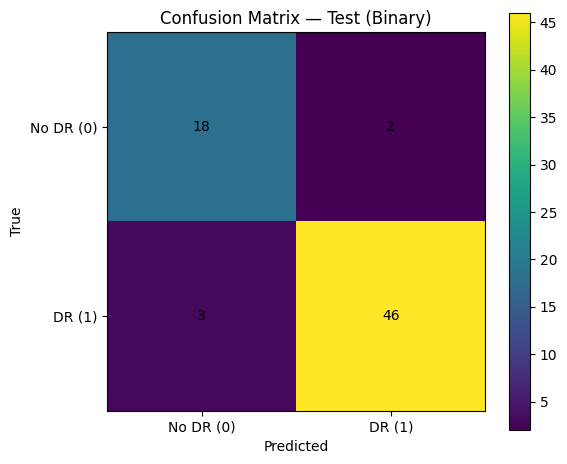

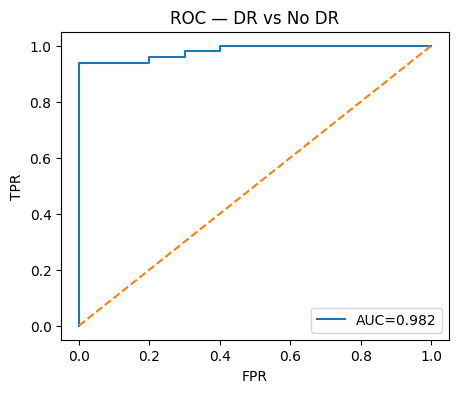

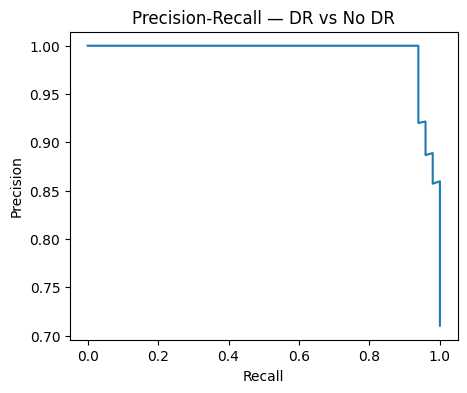

In [10]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, precision_recall_curve

hp = best["hp"]
finetune_model = make_finetune_model(cluster_model, NUM_CLASSES, dropout_p=hp["dropout"])

criterion_sup = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.AdamW(finetune_model.parameters(), lr=hp["lr"], weight_decay=hp["wd"])
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=FINAL_EPOCHS)

def evaluate_full(model, loader):
    model.eval()
    all_logits, all_y, all_ids = [], [], []
    with torch.no_grad():
        for x, y, ids in loader:
            x = x.to(device)
            logits = model(x)
            all_logits.append(logits.cpu())
            all_y.append(y)
            all_ids += list(ids)
    all_logits = torch.cat(all_logits).numpy()
    all_y = torch.cat(all_y).numpy()
    preds = all_logits.argmax(1)
    acc = accuracy_score(all_y, preds)
    f1b = f1_score(all_y, preds, average="binary")
    return acc, f1b, preds, all_logits, all_y, all_ids

hist = {"train_loss":[], "val_f1":[]}
best_val_f1, best_state = -1, None
for epoch in range(1, FINAL_EPOCHS+1):
    finetune_model.train()
    total_loss, total = 0.0, 0
    for x, y, _ in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = finetune_model(x)
        loss = criterion_sup(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
        total += x.size(0)
    scheduler.step()

    val_acc, val_f1, _, _, _, _ = evaluate_full(finetune_model, val_loader)
    tr_loss = total_loss/total
    hist["train_loss"].append(tr_loss); hist["val_f1"].append(val_f1)
    print(f"[Fine-Tuning Final] Época: {epoch:02d}/{FINAL_EPOCHS} | Loss/Treinamento={tr_loss:.4f} | Validação F1={val_f1:.4f} Acurácia={val_acc:.4f}")
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_state = copy.deepcopy(finetune_model.state_dict())

finetune_model.load_state_dict(best_state)

plt.figure(figsize=(8,4))
plt.plot(hist["train_loss"], label="train_loss")
plt.plot(hist["val_f1"], label="val_f1 (val, binary)")
plt.title("Fine-Tuning (Melhores Hiperparâmetros)")
plt.legend()
plt.show()

test_acc, test_f1, test_preds, test_logits, test_y, test_id = evaluate_full(finetune_model, test_loader)
print(f"Test Accuracy: {test_acc:.4f} | Test F1 (binary): {test_f1:.4f}")

print("\nRelatório de Classificação (Teste):")
target_names = ["No DR (0)", "DR (1)"]
print(classification_report(test_y, test_preds, target_names=target_names, digits=4))

cm = confusion_matrix(test_y, test_preds, labels=[0,1])
plt.figure(figsize=(6,5))
plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix — Test (Binary)")
plt.colorbar()
plt.xticks([0,1], target_names)
plt.yticks([0,1], target_names)
plt.xlabel("Predicted"); plt.ylabel("True")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")
plt.tight_layout()
plt.show()

# ROC & PR
probs = torch.softmax(torch.tensor(test_logits), dim=1).numpy()[:,1]
fpr, tpr, _ = roc_curve(test_y, probs)
auc = roc_auc_score(test_y, probs)
plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, label=f"AUC={auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.title("ROC — DR vs No DR")
plt.xlabel("FPR"); plt.ylabel("TPR")
plt.legend(); plt.show()

prec, rec, _ = precision_recall_curve(test_y, probs)
plt.figure(figsize=(5,4))
plt.plot(rec, prec)
plt.title("Precision-Recall — DR vs No DR")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.show()

## 11. Salva o Modelo

In [11]:
OUT = Path("./outputs")
OUT.mkdir(parents=True, exist_ok=True)
torch.save(finetune_model.state_dict(), OUT/"best_model_binary.pth")

import json as _json
with open(OUT/"best_hyperparams_binary.json", "w") as f:
    _json.dump(best["hp"], f, indent=2)

pd.DataFrame({"id_code": test_id, "true": test_y, "pred": test_preds}).to_csv(OUT/"test_predictions_binary.csv", index=False)
print("Saved:", OUT/"best_model_binary.pth", OUT/"best_hyperparams_binary.json", OUT/"test_predictions_binary.csv")

Saved: outputs/best_model_binary.pth outputs/best_hyperparams_binary.json outputs/test_predictions_binary.csv
